<a href="https://colab.research.google.com/github/RuthlessActuary2023/CAS-RPM-2026-Workshop-Functional-Intro-Python/blob/main/CARFAX_Intro_to_Python_Lesson_4_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 4: Data Visualization

In [ ]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns",25)
pd.set_option("display.max_rows",250)
pd.options.display.float_format = '{:,.2f}'.format

from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 90%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))

## Import the same feather file we used in Lesson 3

In [ ]:
# Code to clone the github repo into colab
!pip install gitpython
import git
import os

repo_url = 'https://github.com/RuthlessActuary2023/CAS-RPM-2025-Python-Workshop.git'
repo_dir = '/content/your-repo'

# Clone if it doesn’t already exist
if not os.path.exists(repo_dir):
    git.Repo.clone_from(repo_url, repo_dir)

In [ ]:
repo_dir = '/content/your-repo'
data4 = pd.read_feather(repo_dir + '/data4.ftr')

## Make a copy that we can edit

In [ ]:
data5 = data4.copy()

## View the column names in data5

In [ ]:
[i for i in data5]

## Bring in a function to get percent exposures and loss ratio.

In [ ]:
facts = [i for i in data5.columns if 'ee_' in i or 'ep_' in i or 'incloss_' in i or 'cc_' in i]
ee_list = [i for i in data5.columns if 'ee_' in i]
agg_dict = {i: 'sum' for i in facts}

covs = ['bi']
ee_list.remove('ee_col')

def eda_table(data,field):
    a = data.groupby([field], dropna = False).agg(agg_dict).reset_index()

    for e in ee_list:
        a[e + '_pct'] = a[e]/a[e].sum()

    for c in covs:
        a['lr_' + c] = a['incloss_' + c]/a['ep_' + c]

    a.drop(columns = facts, inplace = True)

    return a

## Run veh_count_box through the function

In [ ]:
b = eda_table(data5,'veh_count_box')
b

,veh_count_box,ee_bi_pct,lr_bi
0,1,0.21,0.43
1,2,0.39,0.62
2,3,0.23,0.48
3,4,0.17,0.80


## Let's make a chart to visualize Loss Ratio
### First we will plot exposures by vehicle count group

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,6))

b['ee_bi_pct'].plot.bar(stacked=False, ax=ax, alpha=.6)

plt.show()

## Let's get the labels right

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

b['ee_bi_pct'].plot.bar(stacked=False, ax=ax, alpha=0.6)

plt.xticks(ticks = b.index, labels = b['veh_count_box']) ### Added

plt.show()

### Let's add y axis label and title

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

b['ee_bi_pct'].plot.bar(stacked=False, ax=ax, alpha=0.6)

plt.xticks(ticks = b.index, labels = b['veh_count_box'])

ax.set(ylabel='% Exposures', title = 'veh_count_box') ### Added

plt.show()

## Now let's add Loss Ratio

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
ax2  = ax.twinx()

b['ee_bi_pct'].plot.bar(stacked=False, ax=ax, alpha=0.6)
b['lr_bi'].plot(kind='line', ax=ax2, marker='o', color = 'yellow', legend = '1')

plt.xticks(ticks = b.index, labels = b['veh_count_box'])

ax.set(ylabel='% of Exposures', title = 'veh_count_box')
# ax2.set(ylabel='Claim Frequency', title = 'veh_count_box') # removed

plt.show()

# colors: https://matplotlib.org/stable/gallery/color/named_colors.html

## Let's finish making our function

In [ ]:
def lr_plot(df, var, weight):
    b = eda_table(df, var)

    fig, ax = plt.subplots(figsize=(12,6))
    ax2  = ax.twinx()

    b[weight].plot.bar(stacked=False, ax=ax, alpha=0.6)
    b['lr_bi'].plot(kind='line', ax=ax2, marker='o', color = 'yellow', legend = '1')

    plt.xticks(ticks = b.index, labels = b[var])

    ax.set(ylabel='% of Exposures', title = 'Loss Ratio by ' + var)
    # ax2.set(ylabel='Claim Frequency', title = 'veh_count_box') # removed

    print(b)

    plt.show()


   veh_count_box  ee_bi_pct  lr_bi
0              1       0.21   0.43
1              2       0.39   0.62
2              3       0.23   0.48
3              4       0.17   0.80


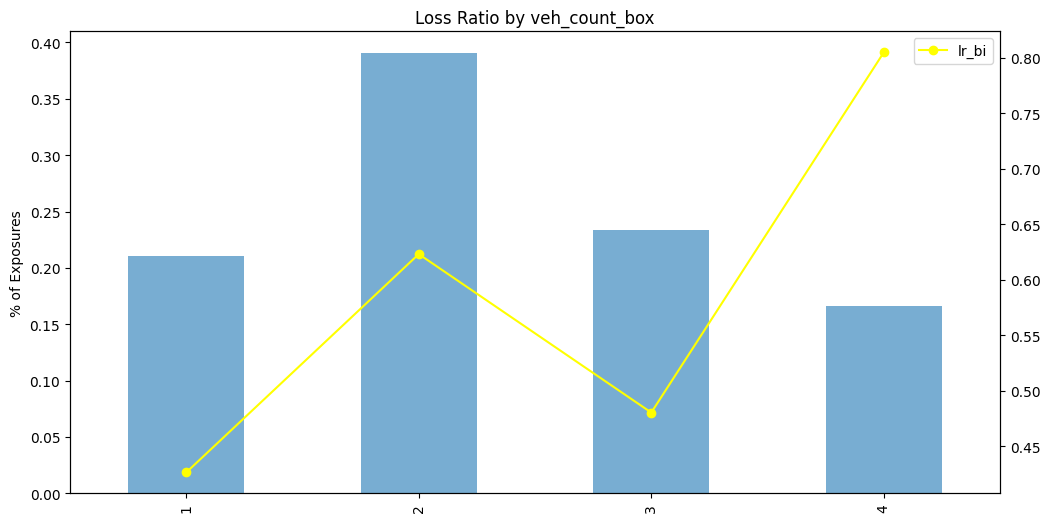

In [ ]:
lr_plot(data5, 'veh_count_box', 'ee_bi_pct')

   driver_count_box  ee_bi_pct  lr_bi
0                 1       0.22   0.72
1                 2       0.53   0.35
2                 3       0.15   0.88
3                 4       0.10   0.62


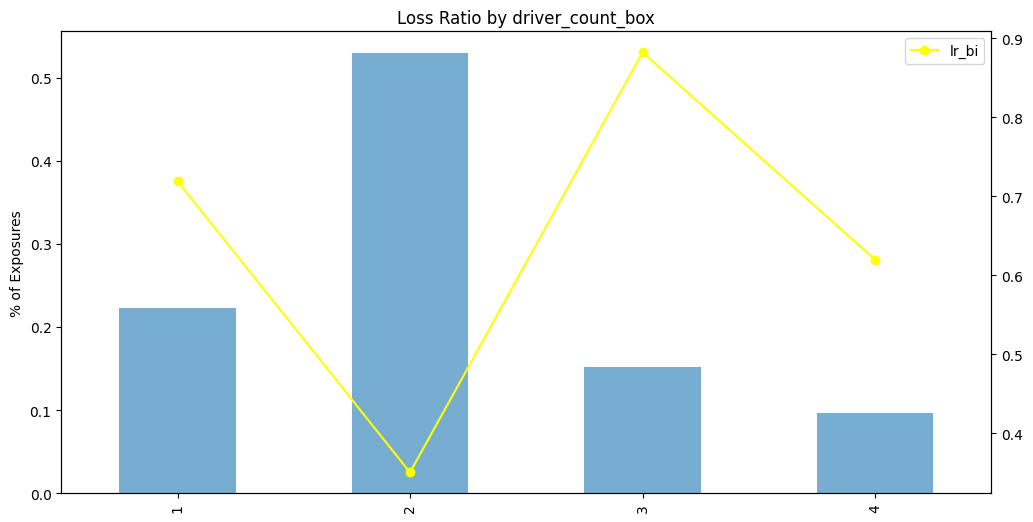

In [ ]:
lr_plot(data5, 'driver_count_box', 'ee_bi_pct')

## Now let's make a widget to easily view the chart
### Determine what fields we don't want to include in the widget display

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

avail_fields = [i for i in data5 if i not in ['ep_bi',
                                              'ep_col',
                                              'ee_bi',
                                              'ee_col',
                                              'incloss_bi',
                                              'incloss_col',
                                              'cc_bi',
                                              'cc_col',
                                              'pol_id',
                                              'zip',
                                              'vin_id',
                                              'Date',
                                              'Modeled_Annual_Mileage',
                                              'Estimated_Current_Mileage',
                                              'Annual_Mileage_Estimate']]

def widget(field):
    return lr_plot(data5, field, 'ee_bi_pct')

interact(widget, field = avail_fields);

## We can also use Plotly Express Plots
#### There are lots of visualization ideas here: https://plotly.com/python/plotly-express/

In [ ]:
import plotly.express as px

## Scatter Plots

In [ ]:
df2 = data5.copy() #make a copy of df so we don't mess up our original
df2['loss_ratio_bi'] = df2['incloss_bi'] / df2['ep_bi']

fig = px.scatter(df2, x='loss_ratio_bi', y='veh_count_box')
fig.show()

## Box Plot

In [ ]:
fig = px.box(df2, x = 'pol_eff_year', y='pop_density_ntile')

fig.show()

## Density Heatmap

In [ ]:
fig = px.density_heatmap(df2, x='unemployment_ntile', y='pol_eff_year', z='ep_bi', histfunc='sum', color_continuous_scale='Reds')
fig.show()

## Choropleth - Zips
### We will need zip to be a string

In [ ]:
data5['zip'].dtypes

dtype('uint16')

In [ ]:
import json
import requests

# found this by searching - we import this geojson file and convert to json
# plotly uses geojson rather than shapefiles.  If you've used arcgis in school you may have used shapefiles before.

zcta = requests.get('https://raw.githubusercontent.com/OpenDataDE/State-zip-code-GeoJSON/master/oh_ohio_zip_codes_geo.min.json').json()

zip_agg = eda_table(data5,'zip')

# add leading zeros and convert to string
zip_agg['zip'] = zip_agg['zip'].astype(str).str.zfill(5) # zfill is a built-in method to zero fill numbers

fig = px.choropleth(
    zip_agg,
    geojson=zcta,
    locations='zip',
    featureidkey='properties.ZCTA5CE10',
    color='lr_bi',
    color_continuous_scale='RdBu_r',
    range_color = (0, 1),
    color_continuous_midpoint = data5['incloss_bi'].sum() / data5['ep_bi'].sum(), #midpoint at the mean loss ratio
    scope='usa'
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(width=900, height=900)
fig.show()

# Lesson 4 Exercise 1
## Modify the widget so that the chart displays % of Exposures and Pure Premium Relativity.
## This requires changing one or more of the items within the block of code in eda_table